# **PFC Self-Administration**
### *A peri-event temporal analysis of excitatory and inhibitory neural activity*

<br>

*Written by*: Joshua Boquiren

[![](https://img.shields.io/badge/@thejoshbq-grey?style=for-the-badge&logo=github)](https://github.com/thejoshbq)
[![](https://img.shields.io/badge/@thejoshbq-grey?style=for-the-badge&logo=X)](https://x.com/thejoshbq)
[![](https://img.shields.io/badge/Otis_Lab-grey?style=for-the-badge)](https://www.otis-lab.org/)

In [1]:
# System I/O
import os
import joblib
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Statistics tools
from scipy.stats import gaussian_kde

# Models
from sklearn.mixture import GaussianMixture

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Custom Python library
from pynapse.config.events import LEGACY_HER
from pynapse.analysis.preprocessing.epoch.pipelines import *
from pynapse.analysis.peri_event import *

In [4]:
def create_population_tensor(dir: str):
    sample_names = [s for s in os.listdir(dir) if os.path.isdir(os.path.join(dir, s))]
    samples = []
    for s in sample_names:
        sample_dir = os.path.join(dir, s)
        FOVs = [f for f in os.listdir(sample_dir) if os.path.isdir(os.path.join(sample_dir, f))]
        for f in FOVs:
            FOV_dir = os.path.join(sample_dir, f)
            mat_files = [os.path.join(FOV_dir, m) for m in os.listdir(FOV_dir) if
                         m.endswith(".mat") and "popevents" not in m]
            npy_files = [os.path.join(FOV_dir, n) for n in os.listdir(FOV_dir) if
                         n.endswith(".npy") and "extracted" in n]
            try:
                sample = Sample(
                    event_data=mat_files,
                    signal_data=npy_files,
                    name=s,
                    fps=30,
                    frame_averaging=4,
                    frame_correction=False,
                    correction_file=None,
                    event_dict=LEGACY_HER
                )
                samples.append(sample)
            except Exception as e:
                print(f"  Sample {s} failed ({e}); skipping")
                continue
    if len(samples) == 0:
        return None
    population = Population(name=dir, samples=samples)
    population_tensor = PopulationEventTensor(
        population,
        event_id=[22, 222],
        pre_event=10,
        post_event=11.6,
        min_trials=3,
        buffer_ms=1000,
        trace_preprocess=None,
        window_preprocess=OTIS_PIPE,
    )
    return population_tensor

data_dir = "./data"
data = {}
for population in sorted(os.listdir(data_dir)):
    if not os.path.isdir(os.path.join(data_dir, population)):
        continue
    if population.startswith('.'):
        continue
    population_tensor = create_population_tensor(os.path.join(data_dir, population))
    if population_tensor is not None:
        data[population] = population_tensor

C:\Users\boqui\OneDrive\Desktop\Projects\pynapse\pynapse\core\io\behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
C:\Users\boqui\OneDrive\Desktop\Projects\pynapse\pynapse\core\io\behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
C:\Users\boqui\OneDrive\Desktop\Projects\pynapse\pynapse\core\io\behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)


KeyboardInterrupt: 

Saved plot to ./fig


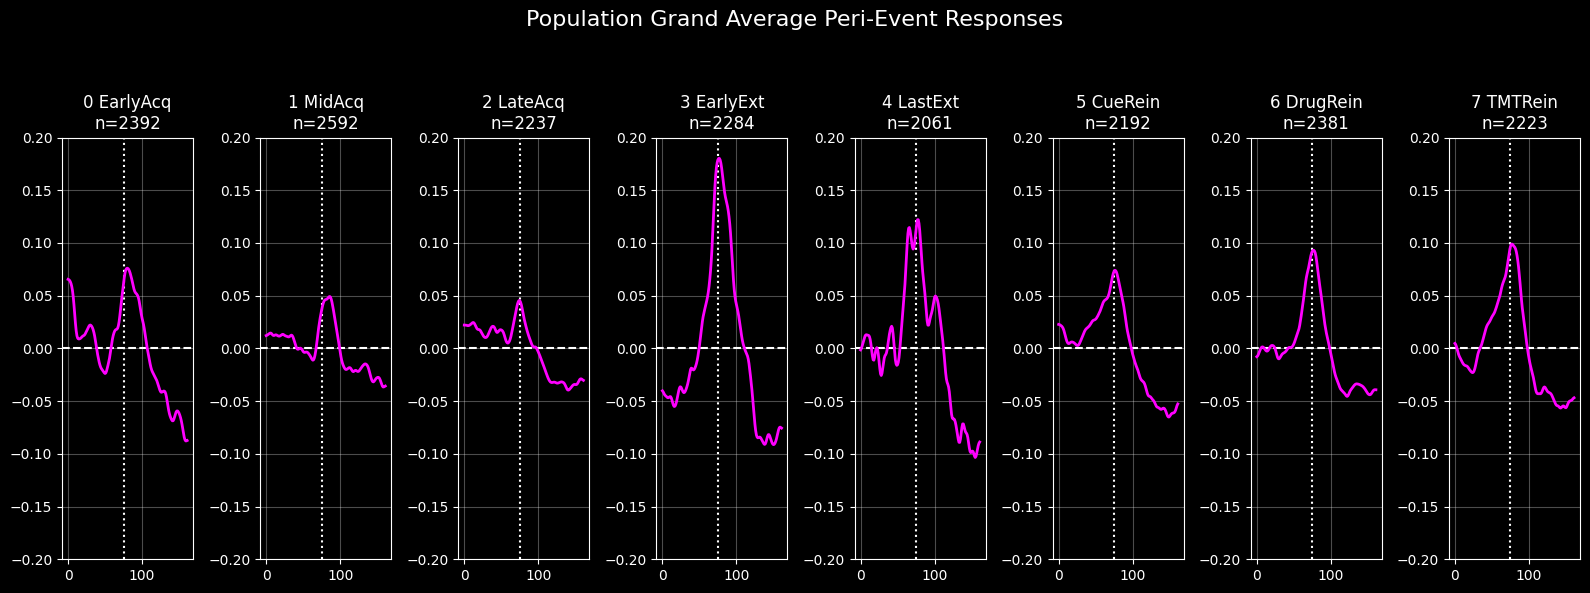

In [11]:
def plot_perievent_population_grand_avg_response(data: dict, output: str | None=None):
    n_pops = len(data)
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, len(data.items()), figsize=(16, 6))
    for col, population_name in enumerate(data):
        tensor = data.get(population_name)
        grand_avg = tensor.get_grand_average()
        event_frame = 75
        axs[col].axhline(0, color="white", linestyle="--")
        axs[col].axvline(event_frame, color="white", linestyle=":")
        axs[col].set_ylim(-0.2, 0.2)
        axs[col].grid(True, alpha=0.3)
        axs[col].plot(grand_avg, linewidth=2, color="magenta")
        axs[col].set_title(f"{population_name}\nn={tensor.num_neurons}")
    plt.suptitle("Population Grand Average Peri-Event Responses\n\n", fontsize=16)
    plt.tight_layout()
    if output:
        plt.savefig(os.path.join(output, "grand_avg_response.jpg"), dpi=300, bbox_inches='tight')
        print(f"Saved plot to {output}")
    plt.show()

plot_perievent_population_grand_avg_response(data, "./fig")

Saved plot to ./fig


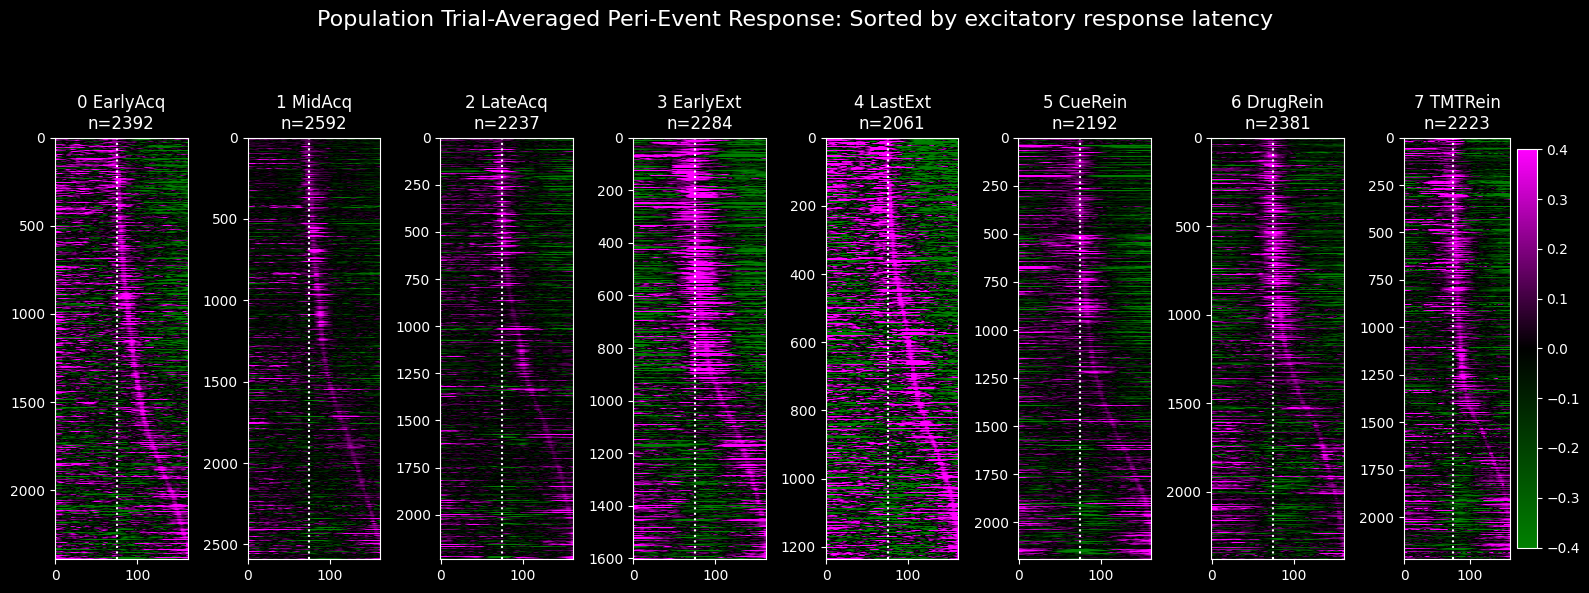

In [10]:
def plot_perievent_trial_mean(data: dict, sort: str = None, output: str | None=None):
    n_pops = len(data)
    subtitle = ""
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, len(data.items()), figsize=(16, 6))
    for col, population_name in enumerate(data):
        tensor = data.get(population_name)
        event_frame = 75
        custom_cmap = LinearSegmentedColormap.from_list("GreenBlackMagenta", ["green", "black", "magenta"])
        avg_excitatory = tensor.get_trial_average(epoch="post_event", method="excitatory")
        im = axs[col].imshow(avg_excitatory, aspect='auto', cmap=custom_cmap, vmin=-0.4, vmax=0.4, interpolation='nearest')
        axs[col].axhline(0, color="white", linestyle="--")
        axs[col].axvline(event_frame, color="white", linestyle=":")
        axs[col].set_title(f"{population_name}\nn={tensor.num_neurons}")
        if col == (len(data) - 1):
            fig.colorbar(im, ax=axs[col])
    plt.suptitle(f"Population Trial-Averaged Peri-Event Response: Sorted by excitatory response latency\n\n", fontsize=16)
    plt.tight_layout()
    if output:
        plt.savefig(os.path.join(output, f"trial_avg_excitatory_response_latency.jpg"), dpi=300, bbox_inches='tight')
        print(f"Saved plot to {output}")
    plt.show()

plot_perievent_trial_mean(data=data, output="./fig")

In [ ]:
def plot_post_event_kde(data: dict, output: str | None=None):
    n_pops = len(data)
    stages = sorted(data.keys())
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, n_pops, figsize=(16, 6))
    if n_pops == 1:
        axs = [axs]
    event_frame = 75
    fps = 7.5
    post_seconds = 10.0
    all_densities = []
    exc_kde_data = {}
    inh_kde_data = {}
    for stage_name, data in data.items():
        post_slice = data[:, event_frame:event_frame + int(post_seconds * fps)]
        peak_frames_rel = np.argmax(post_slice, axis=1)
        peak_times_s = peak_frames_rel / fps
        exc_responsive = np.max(post_slice, axis=1) > 0.1
        exc_times = peak_times_s[exc_responsive]
        exc_kde_data[stage_name] = exc_times
        if len(exc_times) > 0:
            kde = gaussian_kde(exc_times)
            x = np.linspace(0, post_seconds, 300)
            all_densities.append(kde(x).max())
        trough_frames_rel = np.argmin(post_slice, axis=1)
        trough_times_s = trough_frames_rel / fps
        inh_responsive = np.min(post_slice, axis=1) < -0.1
        inh_times = trough_times_s[inh_responsive]
        inh_kde_data[stage_name] = inh_times
        if len(inh_times) > 0:
            kde = gaussian_kde(inh_times)
            x = np.linspace(0, post_seconds, 300)
            all_densities.append(kde(x).max())
    global_max_density = max(all_densities) * 1.1 if all_densities else 1.0
    for col, stage_name in enumerate(stages):
        ax = axs[col]
        exc_times = exc_kde_data[stage_name]
        if len(exc_times) > 0:
            kde = gaussian_kde(exc_times)
            x = np.linspace(0, post_seconds, 300)
            y = kde(x)
            ax.plot(x, y, color='magenta', linewidth=3, label=f"Exc Peaks (n={len(exc_times)})")
            ax.fill_between(x, y, alpha=0.3, color='magenta')
        inh_times = inh_kde_data[stage_name]
        if len(inh_times) > 0:
            kde = gaussian_kde(inh_times)
            x = np.linspace(0, post_seconds, 300)
            y = kde(x)
            ax.plot(x, y, color='green', linewidth=3, label=f"Inh Troughs (n={len(inh_times)})")
            ax.fill_between(x, y, alpha=0.3, color='green')
        ax.set_title(f"{stage_name}", color='white')
        ax.set_xlabel("Latency Post-Press (s)", color='white')
        ax.set_ylabel("Density", color='white')
        ax.set_ylim(0, global_max_density)
        ax.tick_params(colors='white')
        ax.grid(True, alpha=0.3)
    fig.suptitle("Post-Event Latency KDEs: Excitation vs. Inhibition\n\n",
                 fontsize=16, color='white')
    plt.tight_layout()
    if output:
        plt.savefig(os.path.join(output, "post_event_kde.jpg"), dpi=300, bbox_inches='tight')
        print(f"Saved plot to {output}")
    plt.show()

plot_post_event_kde(data, "./fig")

In [ ]:
def cluster_post_event_subpopulations(population_data: dict, max_clusters: int = 12):
    event_frame = 75
    fps = 7.5
    post_frames = int(8 * fps)
    clustered_data = {}
    for stage_name, data in sorted(population_data.items()):
        print(f"\n=== Clustering post-event in {stage_name} ===")
        post_slice = data[:, event_frame:event_frame + post_frames]
        responsive = np.ptp(post_slice, axis=1) > 0.2
        cluster_data = post_slice[responsive]
        if cluster_data.shape[0] < 2:
            print(f"  Too few responsive neurons — skipping")
            clustered_data[stage_name] = {'skipped': True}
            continue
        scaler = StandardScaler()
        scaled = scaler.fit_transform(cluster_data.T).T
        pca = PCA(n_components=0.95, random_state=42)
        reduced = pca.fit_transform(scaled)
        print(f"  PCA components: {pca.n_components_}")
        print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
        bics = []
        ks = range(2, max_clusters + 1)
        for k in ks:
            gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
            gmm.fit(reduced)
            bics.append(gmm.bic(reduced))
        optimal_k = ks[np.argmin(bics)]
        print(f"  Optimal k = {optimal_k} (lowest BIC)")
        gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
        labels = gmm.fit_predict(reduced)
        cluster_peaks = [np.mean(np.argmax(cluster_data[labels == c], axis=1)) for c in range(optimal_k)]
        order = np.argsort(cluster_peaks)
        sorted_labels = np.zeros_like(labels)
        for new, old in enumerate(order):
            sorted_labels[labels == old] = new
        cluster_means = np.array([np.nanmean(cluster_data[labels == order[c]], axis=0) for c in range(optimal_k)])
        proportions = np.bincount(sorted_labels.astype(int), minlength=optimal_k) / len(labels)
        sorted_data = cluster_data[np.argsort(sorted_labels)]
        clustered_data[stage_name] = {
            'original_data': data,
            'post_slice': post_slice,
            'responsive_mask': responsive,
            'optimal_k': optimal_k,
            'labels': sorted_labels,  # 0 to k-1, sorted by peak time
            'sorted_data': sorted_data,
            'cluster_means': cluster_means,
            'proportions': proportions,
            'bic_values': bics,
            'pca_explained': pca.explained_variance_ratio_.sum()
        }
    return clustered_data

clustered_dict = cluster_post_event_subpopulations(data)

In [ ]:
def plot_clustering_per_stage(clustered_dict: dict, output: str | None=None):
    for stage_name, info in clustered_dict.items():
        if 'skipped' in info:
            print(f"Skipping visualization for {stage_name} (no data)")
            continue
        optimal_k = info['optimal_k']
        sorted_data = info['sorted_data']
        cluster_means = info['cluster_means']
        proportions = info['proportions']
        bics = info['bic_values']
        ks = range(2, len(bics) + 2)
        cluster_sizes = (proportions * len(sorted_data)).astype(int)
        boundaries = np.cumsum(cluster_sizes)[:-1]
        fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='black')
        fig.suptitle(stage_name, fontsize=16, color='white')
        axes[0].plot(ks, bics, marker='o', color='cyan')
        axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'k={optimal_k}')
        axes[0].set_title("BIC Elbow", color='white')
        axes[0].set_xlabel("k", color='white')
        axes[0].set_ylabel("BIC", color='white')
        axes[0].tick_params(colors='white')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        custom_cmap = LinearSegmentedColormap.from_list("GreenBlackMagenta", ["green", "black", "magenta"])
        axes[1].imshow(sorted_data, aspect='auto', cmap=custom_cmap, vmin=-0.4, vmax=0.4)
        axes[1].axvline(0, color='white', linestyle='--')
        for b in boundaries:
            axes[1].hlines(b, xmin=0, xmax=sorted_data.shape[1], color='red', linewidth=3, linestyle="--")
        axes[1].set_title(f"Clustered Heatmap (k={optimal_k})", color='white')
        axes[1].set_xlabel("Frames Post-Press", color='white')
        axes[1].set_ylabel("Neurons", color='white')
        axes[1].tick_params(colors='white')
        for c in range(optimal_k):
            mean = cluster_means[c]
            prop = proportions[c] * 100
            axes[2].plot(mean, label=f"Cluster {c + 1} ({prop:.1f}%)")
        axes[2].axvline(0, color='white', linestyle='--')
        axes[2].set_title("Cluster Mean Traces", color='white')
        axes[2].set_xlabel("Frames Post-Press", color='white')
        axes[2].set_ylabel("Activity", color='white')
        axes[2].set_ylim(-0.45, 0.7)
        axes[2].tick_params(colors='white')
        axes[2].legend(facecolor='black', framealpha=0.8)
        axes[2].grid(True, alpha=0.3)
        plt.tight_layout()
        if output:
            plt.savefig(os.path.join(output, f"{stage_name}_clustering.jpg"), dpi=300, bbox_inches='tight')
            print(f"Saved plot to {output}")
        plt.show()

plot_clustering_per_stage(clustered_dict, "./fig")